In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


In [3]:
train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)
train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)
test_paths, test_labels = shuffle(test_paths, test_labels)


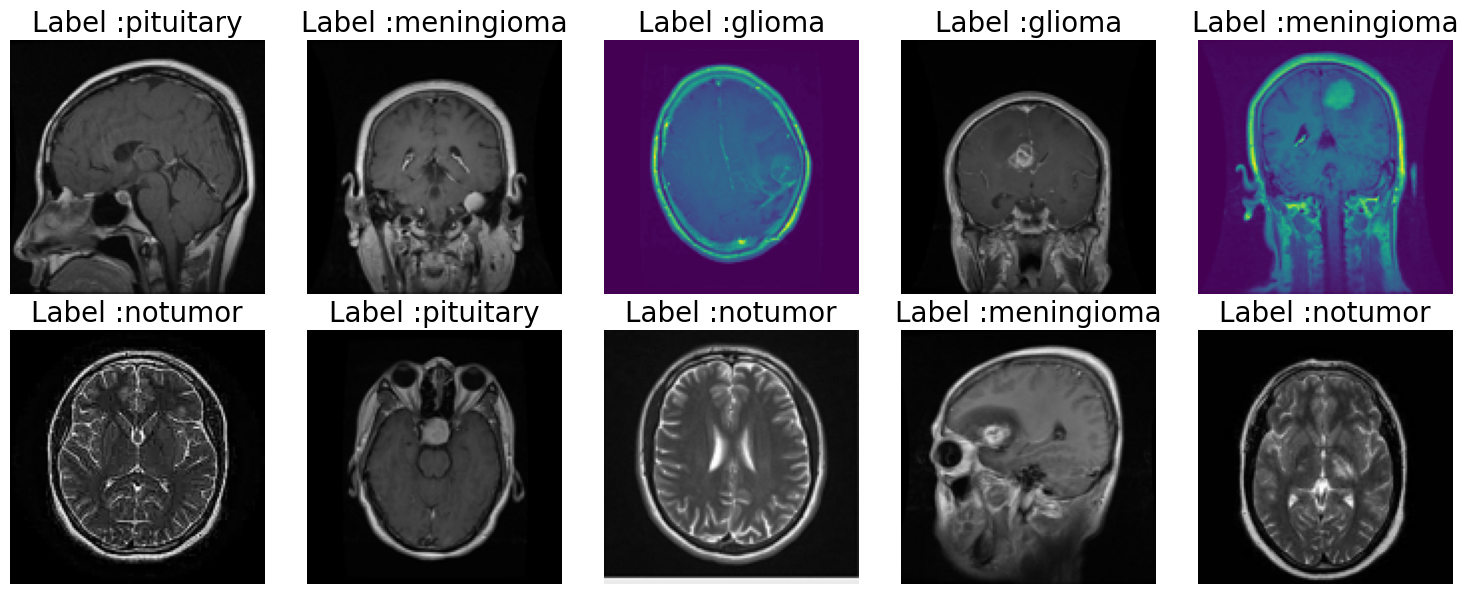

In [4]:
import matplotlib.pyplot as plt
random_indices = random.sample(range(len(train_paths)), 10)
figs, axes = plt.subplots(2, 5, figsize = (15, 6))
axes = axes.ravel()
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label :{train_labels[idx]}", fontsize=20)
plt.tight_layout()
plt.show()

In [6]:
def augement_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.3))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.3))
  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8, 1.3))
  image = np.array(image)/255.0
  return image


def open_images(paths):
  images  = []
  for path in paths:
    img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img = augement_image(img)
    images.append(img)
  return np.array(images)


def encode_label(labels):
  unique_labels = sorted(os.listdir(train_dir))
  encoded = [unique_labels.index(label) for label in labels]
  return encoded


def datagen(paths, labels, batch_size=12, epochs=1):
  for _ in range(epochs):
    shuffled_paths, shuffled_labels = shuffle(paths, labels)
    for i in range(0, len(shuffled_paths), batch_size):
      batch_paths = shuffled_paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = shuffled_labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, np.array(batch_labels)

In [7]:
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')
for layer in base_model.layers:
  layer.trainable = False
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 10

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1272s 5s/step - loss: 0.4747 - sparse_categorical_accuracy: 0.8164
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1221s 4s/step - loss: 0.2435 - sparse_categorical_accuracy: 0.9080
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1226s 4s/step - loss: 0.1703 - sparse_categorical_accuracy: 0.9346
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1216s 4s/step - loss: 0.1279 - sparse_categorical_accuracy: 0.9536
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1230s 4s/step - loss: 0.0938 - sparse_categorical_accuracy: 0.9648
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1229s 4s/step - loss: 0.0610 - sparse_categorical_accuracy: 0.9782
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1242s 4s/step - loss: 0.0545 - sparse_categorical_accuracy: 0.9805
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1220s 4s/step - loss: 0.0389 - sparse_categorical_accuracy: 0.9859
Epoch 9/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1237s 4s/step - loss: 0.0412 - sparse_categorical_acc

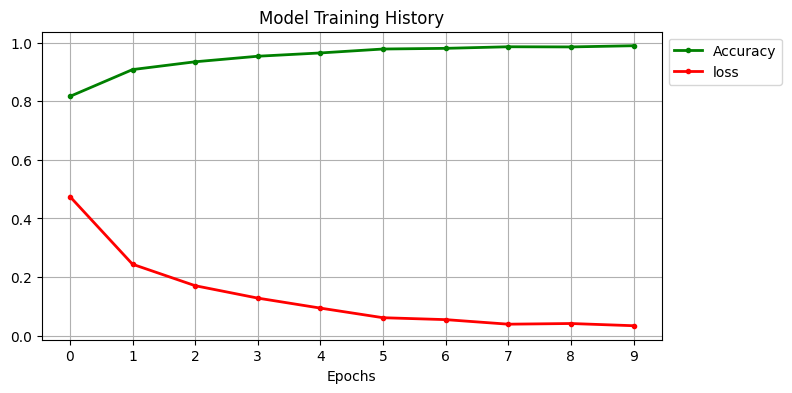

In [8]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)
test_predictions = model.predict(test_images)
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))



50/50 ━━━━━━━━━━━━━━━━━━━━ 291s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       400
           1       0.79      0.97      0.87       400
           2       0.96      0.98      0.97       400
           3       0.98      0.95      0.97       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



Confusion Matrix:
[[304  77  16   3]
 [  9 387   1   3]
 [  0   6 394   0]
 [  2  17   0 381]]


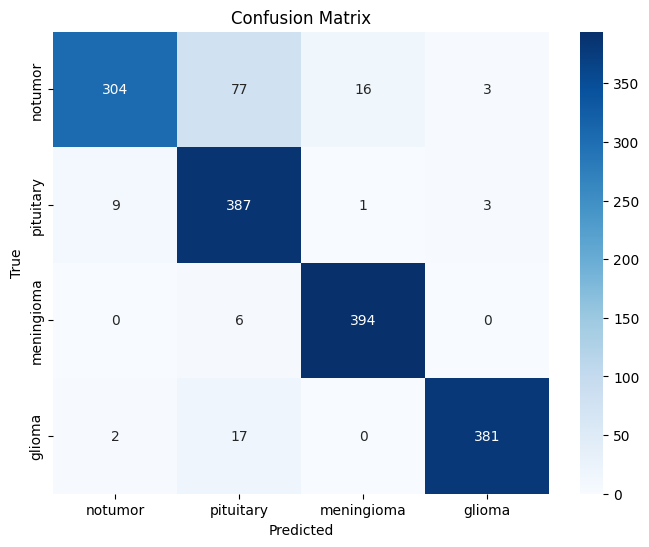

In [10]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

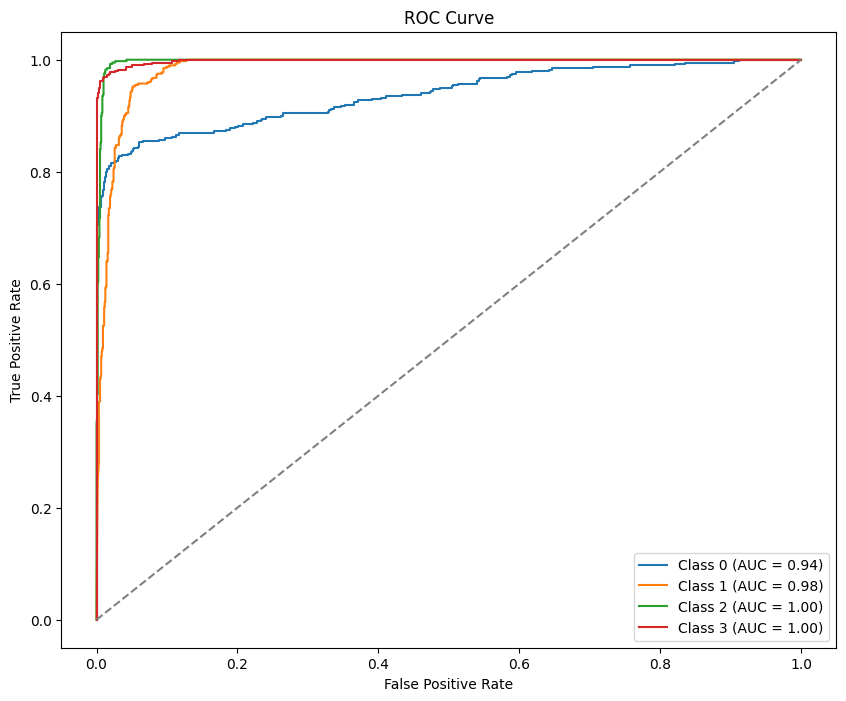

In [11]:
test_label_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
  fpr[i], tpr[i], _ = roc_curve(test_label_bin[:, i], test_predictions_bin[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
  plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()



In [12]:
model.save('model.h5')

In [13]:
from tensorflow.keras.models import load_model
model = load_model('model.h5')

In [14]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

class_labels = sorted(os.listdir(train_dir))

def detect_and_diplay(image_path, model):
  try:
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions)
    confidence_score = np.max(predictions, axis=1)[0]

    if class_labels[predicted_class_index] == 'notumor':
      result =  "No Tumor Detected"
    else:
      result = f"Tumor: {class_labels[predicted_class_index]}"

    plt.imshow(load_img(image_path))
    plt.axis('off')
    plt.title(f"{result} (confidence:) {confidence_score * 100:.2f}%")
    plt.show()


  except Exception as e:
    print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


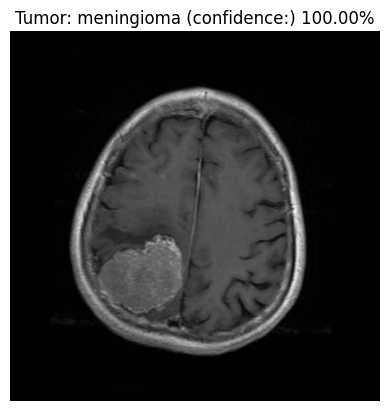

In [15]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-aug-me_36.jpg'
detect_and_diplay(image_path, model)